<a href="https://colab.research.google.com/github/Seungkyu-Han/deep_learning/blob/main/ch6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
class SGD:

  def __init__(
      self,
      learning_rate: float = 0.01,
  ):
    self.learning_rate = learning_rate

  def update(
      self,
      params,
      grads,
  ):
    for key in params.keys():
      params[key] -= self.learning_rate * grads[key]
    return params

In [ ]:
class Momentum:

  def __init__(
      self,
      learning_rate: float = 0.01,
      momentum: float = 0.9,
  ):
    self.learning_rate = learning_rate
    self.momentum = momentum
    self.v = None

  def update(
      self,
      params,
      grads,
  ):
    if self.v is None:
      self.v = {}
      for key, val in params.items():
        self.v[key] = np.zeros_like(val)

    for key in params.keys():
      self.v[key] = self.momentum * self.v[key]  - self.learning_rate*grads[key]
      params[key] += self.v[key]

In [ ]:
import numpy as np

class AdaGrad:

  def __init__(
      self,
      learning_rate: float = 0.01
  ):
    self.learning_rate = learning_rate
    self.h = None

  def update(
      self,
      params,
      grads,
  ):
    if self.h is None:
      self.h = {}
      for key, val in params.items():
        self.h[key] = np.zeros_like(val)

    for key in params.keys():
      self.h[key] += grads[key] * grads[key]
      params[key] -= self.learning_rate * grads[key] / (np.sqrt(self.h[key]) + 1e-7)

In [ ]:
class Adam:

  def __init__(
      self,
      learning_rate: float = 0.001,
      beta1: float = 0.9,
      beta2: float = 0.999,
  ):
    self.learning_rate = learning_rate
    self.beta1 = beta1
    self.beta2 = beta2
    self.iter = 0
    self.m = None
    self.v = None

  def update(
      self,
      params,
      grads,
  ):
    if self.m is None:
      self.m, self.v = {}, {}
      for key, val in params.items():
        self.m[key] = np.zeros_like(val)
        self.v[key] = np.zeros_like(val)

    self.iter += 1

    learning_rate_t = self.learning_rate * np.sqrt(1.0 - self.beta2**self.iter) / (1.0 - self.beta1**self.iter)

    for key in params.keys():
      self.m[key] += (1 - self.beta1) * (grads[key] - self.m[key])
      self.v[key] += (1 - self.beta2) * (grads[key]**2 - self.v[key])

      params[key] -= learning_rate_t * self.m[key] / (np.sqrt(self.v[key]) + 1e-7)


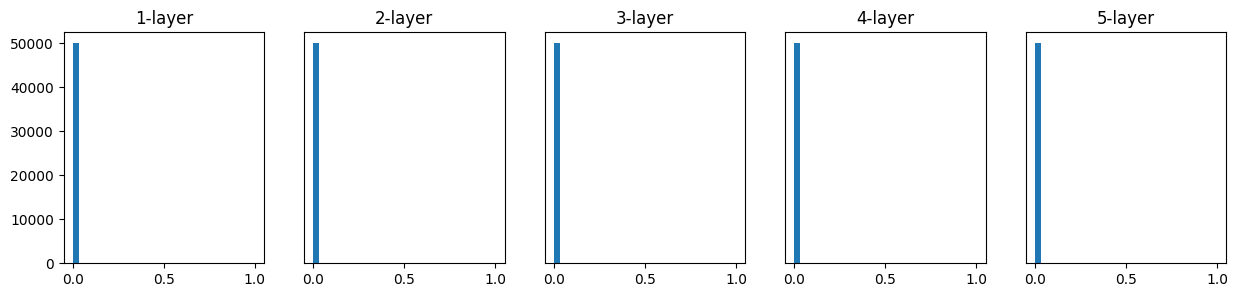

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def ReLU(x):
    return np.maximum(0, x)

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        # 이전 레이어의 출력을 다음 레이어의 입력으로 사용
        x = activations[i-1]

    # 가중치 초기화 (표준편차 1인 정규분포)
    w = np.random.randn(x.shape[1], node_num)
    a = np.dot(x, w)
    z = ReLU(a)

    # 활성화 값을 딕셔너리에 저장 (i=0일 때도 정상 저장됨)
    activations[i] = z

# 히스토그램 그리기
plt.figure(figsize=(15, 3)) # 그래프가 겹치지 않도록 가로 크기 조절
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))
    if i > 0:
        plt.gca().axes.get_yaxis().set_visible(False) # 가독성을 위해 y축 숨기기
plt.show()

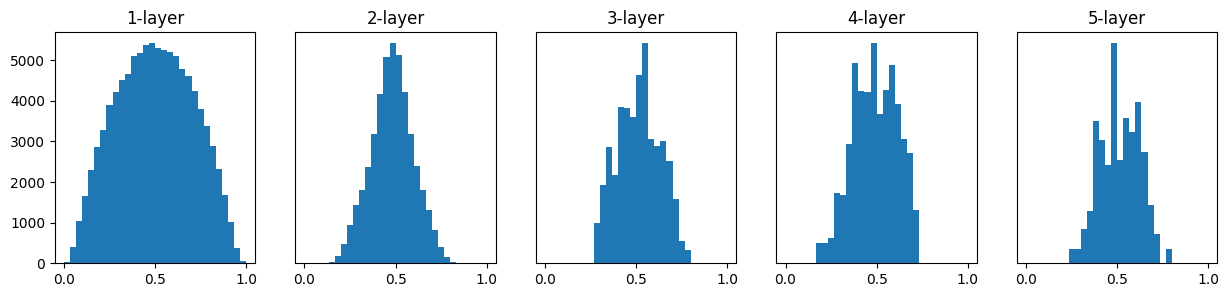

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        # 이전 레이어의 출력을 다음 레이어의 입력으로 사용
        x = activations[i-1]

    # -------------------------------------------------------------
    # [수정] Xavier 초기화 적용
    # 앞 층의 노드 수(x.shape[1])의 제곱근으로 나누어 표준편차를 조절합니다.
    # -------------------------------------------------------------
    w = np.random.randn(x.shape[1], node_num) / np.sqrt(x.shape[1])

    a = np.dot(x, w)
    z = sigmoid(a)

    # 활성화 값을 딕셔너리에 저장
    activations[i] = z

# 히스토그램 그리기
plt.figure(figsize=(15, 3))
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    plt.hist(a.flatten(), 30, range=(0,1))
    if i > 0:
        plt.gca().axes.get_yaxis().set_visible(False)
plt.show()

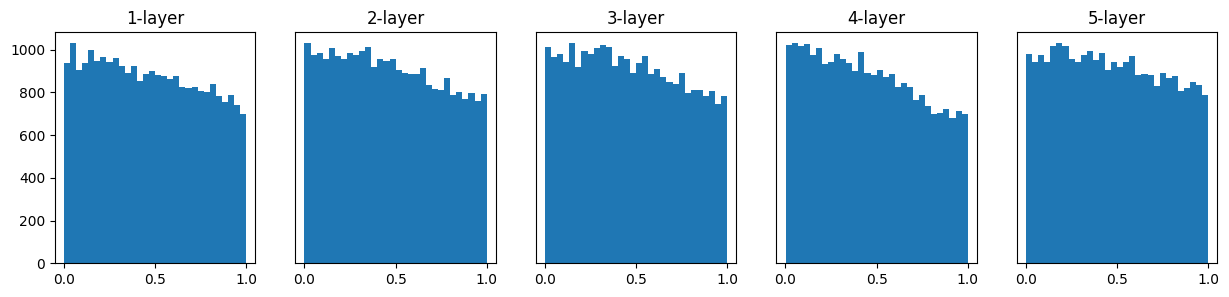

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ReLU 함수 정의
def ReLU(x):
    return np.maximum(0, x)

x = np.random.randn(1000, 100)
node_num = 100
hidden_layer_size = 5
activations = {}

for i in range(hidden_layer_size):
    if i != 0:
        # 이전 레이어의 출력을 다음 레이어의 입력으로 사용
        x = activations[i-1]

    # -------------------------------------------------------------
    # [수정] He 초기화 적용 (He Initialization)
    # ReLU 활성화 함수에 맞춰 표준편차를 np.sqrt(2 / n)로 설정합니다.
    # -------------------------------------------------------------
    w = np.random.randn(x.shape[1], node_num) * np.sqrt(2.0 / x.shape[1])

    a = np.dot(x, w)
    z = ReLU(a)  # ReLU 활성화 함수 사용

    # 활성화 값을 딕셔너리에 저장
    activations[i] = z

# 히스토그램 그리기
plt.figure(figsize=(15, 3))
for i, a in activations.items():
    plt.subplot(1, len(activations), i+1)
    plt.title(str(i+1) + "-layer")
    # ReLU 특성상 0에 값이 몰리므로 분포를 더 잘 보기 위해 범위를 (0, 1)로 설정
    plt.hist(a.flatten(), 30, range=(0.0001, 1)) # 0을 제외한 양수 분포를 시각화
    if i > 0:
        plt.gca().axes.get_yaxis().set_visible(False)
plt.show()

In [ ]:
class Dropout:

  def __init__(
      self,
      drouput_ratio: float = 0.5
  ):
    self.dropout_ratio = drouput_ratio
    self.mask = None

  def forward(
      self,
      x,
      train_flag = True,
  ):
    if train_flag:
      self.mask = np.random.rand(*x.shape) > self.dropout_ratio
      return x * self.mask
    else:
      return x * (1.0 - self.dropout_ratio)

  def backward(self, dout):
    return dout * self.mask